
# Multivariate time series generation through shared white-noise excitation

The univariate simulators in S2Generator (Wiener filter, Kalman filter, ARIMA, MSAR, Gaussian mixture, etc.) are designed for single-channel sequences. When the input is a **multivariate** time series with shape `[seq_length, n_channels]`, fitting each channel independently and generating them with independent random seeds destroys cross-channel correlation.

The `MultivariateSimulator` addresses this problem by keeping the same white-noise-to-signal philosophy:

1. Fit one univariate simulator on each channel.
2. During generation, drive all `invoke`-capable channels with the **same white-noise excitation**.
3. Because the channel outputs are different linear responses to a common input, the synthesized multivariate series remains cross-correlated.

This notebook introduces the method in the following order:

1. Basic mathematical principles of shared-excitation multivariate generation.
2. A manual construction of a three-channel correlated series.
3. Visualization of channel trajectories and cross-correlation structure.
4. Usage of the encapsulated `MultivariateSimulator` in S2Generator.



## Shared-excitation multivariate modeling

Let a multivariate observation be
$$
\mathbf{y}_t = [y_t^{(1)}, y_t^{(2)}, \ldots, y_t^{(D)}]^\top .
$$

Suppose each channel can be approximated by a learnable linear system driven by a common white-noise process $w_t$:
$$
y_t^{(d)} = h_d * w_t, \quad d = 1, \ldots, D, \quad (1)
$$
where $h_d$ denotes the channel-specific impulse response learned by a univariate simulator such as the Wiener filter or Kalman-filter state-space model.

### Why independent generation is not enough

If we fit each channel separately but generate them with independent noise,
$$
y_t^{(d)} = h_d * w_t^{(d)}, \quad w_t^{(d)} \stackrel{\text{i.i.d.}}{\sim} \mathcal{N}(0, 1),
$$
then channels become statistically independent even when the original data were correlated.

### Shared-excitation generation

The multivariate wrapper instead uses one excitation path per sample:
$$
w_t \sim \mathcal{N}(0, 1), \qquad
y_t^{(d)} = \mathcal{G}_d(w_{t-k_d:t}), \quad (2)
$$
where $\mathcal{G}_d(\cdot)$ is the fitted generation operator of channel $d$ (for example, `invoke` in the Wiener / Kalman simulators).

### Fitting strategy

- **Single simulator template**: every channel is fitted with a deep-copied instance of the same simulator class and hyperparameters.
- **Simulator list**: channel $d$ uses the $d$-th simulator in the list; extra channels default to `WienerFilterSimulator`.
- **Parallel fitting**: when the channel count is large, `fit(..., n_jobs=-1)` fits channels concurrently.

The `MultivariateSimulator` exposes the same `fit` / `transform` interface as the other simulators, but returns arrays with shape `[num_samples, seq_length, n_channels]`.



Below we import the required libraries and build a synthetic three-channel dataset for demonstration.


In [1]:
import numpy as np
from matplotlib import pyplot as plt
import sys
import os

sys.path.append(os.path.abspath(".."))

from s2generator.simulator import (
    MultivariateSimulator,
    WienerFilterSimulator,
    KalmanFilterSimulator,
)
from s2generator.utils import plot_simulator_statistics, plot_univariate_time_series


## Step 1: Generate a synthetic multivariate series with shared white noise

We first construct a three-channel series by passing the same white-noise excitation through three different linear filters. This gives us a ground-truth correlated dataset with shape `[seq_length, n_channels]`.


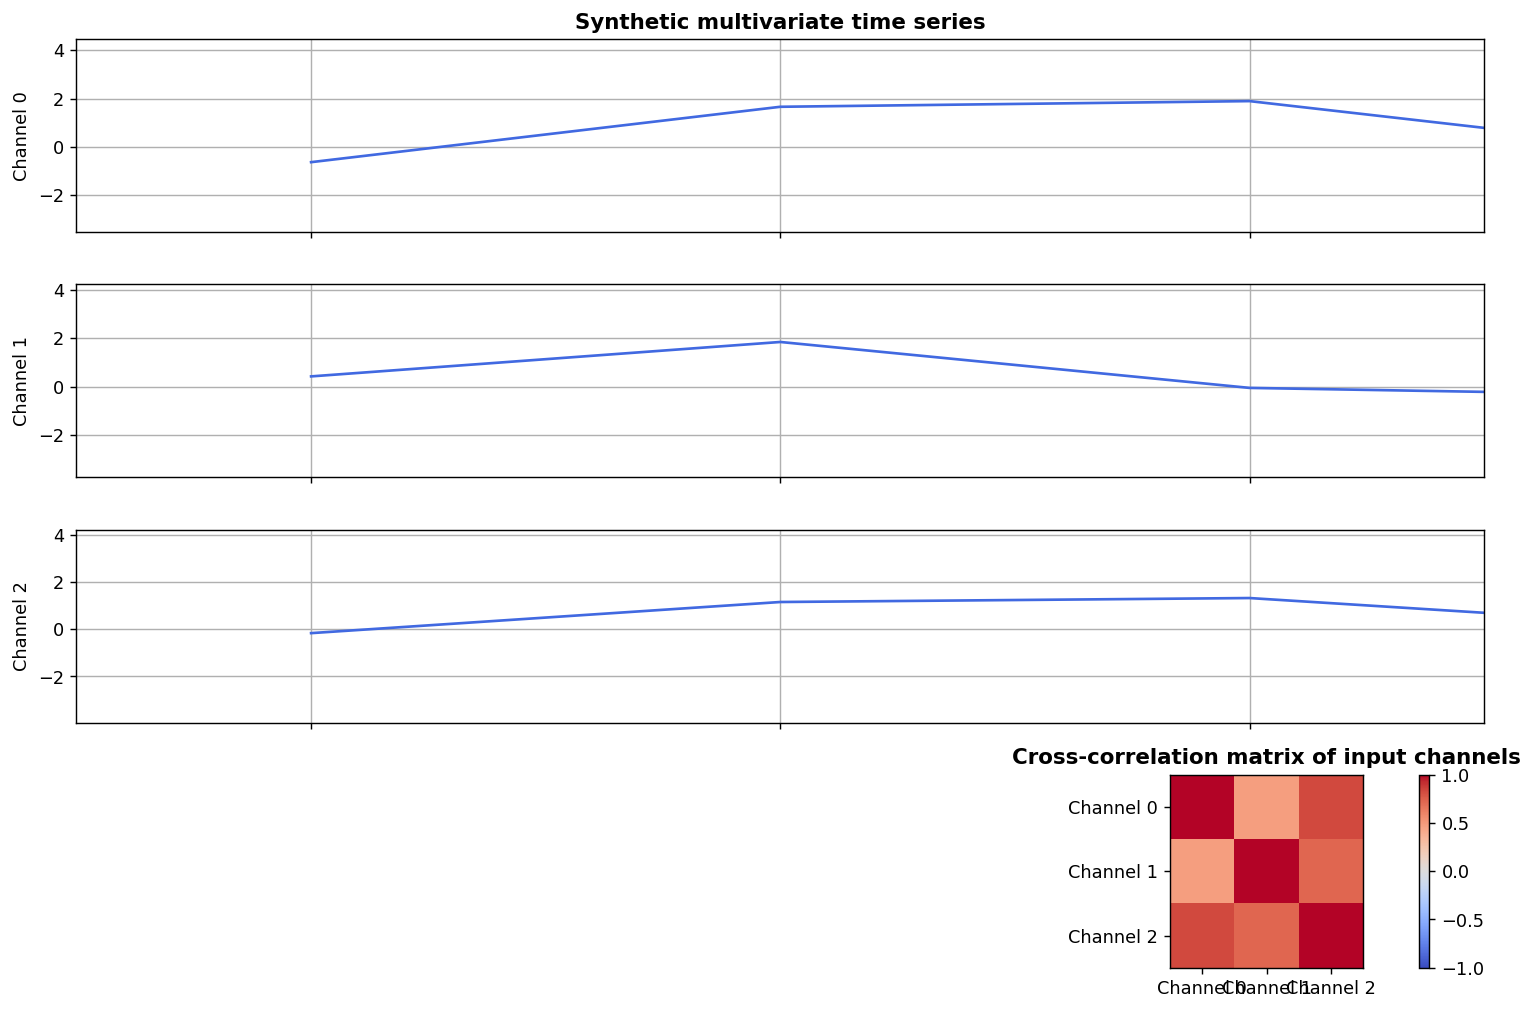

In [ ]:
def generate_shared_noise_multivariate(
    seq_length: int = 600,
    random_state: int = 42,
) -> np.ndarray:
    """Generate a three-channel series from one shared white-noise excitation."""
    rng = np.random.RandomState(random_state)
    white_noise = rng.normal(size=seq_length + 8)

    filters = [
        np.array([1.0, 0.65, -0.20, 0.10, 0.05, 0.0]),
        np.array([1.0, -0.45, 0.30, 0.15, 0.0, 0.0]),
        np.array([1.0, 0.25, 0.20, -0.25, 0.10, 0.0]),
    ]

    channels = []
    for coeff in filters:
        filtered = np.convolve(white_noise, coeff, mode="valid")
        channels.append(filtered[:seq_length])

    return np.stack(channels, axis=1)


seq_length = 600
time_series = generate_shared_noise_multivariate(seq_length=seq_length, random_state=42)
n_channels = time_series.shape[1]

fig, axes = plt.subplots(n_channels + 1, 1, figsize=(12, 8), sharex=True, dpi=128)
channel_names = ["Channel 0", "Channel 1", "Channel 2"]

for idx in range(n_channels):
    axes[idx].plot(time_series[:, idx], color="royalblue")
    axes[idx].set_ylabel(channel_names[idx])
    axes[idx].grid(True)
axes[0].set_title("Synthetic multivariate time series", fontweight="bold")

corr = np.corrcoef(time_series.T)
im = axes[-1].imshow(corr, vmin=-1.0, vmax=1.0, cmap="coolwarm")
axes[-1].set_title("Cross-correlation matrix of input channels", fontweight="bold")
axes[-1].set_xticks(range(n_channels))
axes[-1].set_yticks(range(n_channels))
axes[-1].set_xticklabels(channel_names)
axes[-1].set_yticklabels(channel_names)
fig.colorbar(im, ax=axes[-1], fraction=0.046, pad=0.04)
plt.tight_layout()


## Step 2: Fit one Wiener filter per channel and generate with shared noise

Before using the encapsulated multivariate simulator, we manually fit three `WienerFilterSimulator` instances and generate a new sample by exciting all of them with the same white-noise path through `invoke`.


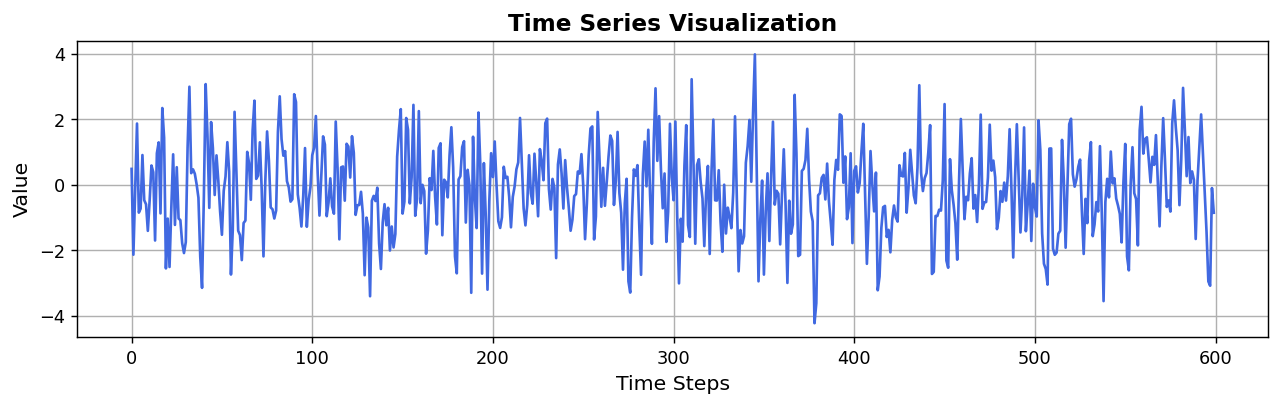

In [3]:
manual_simulators = [
    WienerFilterSimulator(filter_order=6, revin=True, random_state=42)
    for _ in range(n_channels)
]

for channel_index, simulator in enumerate(manual_simulators):
    simulator.fit(time_series[:, channel_index])

rng = np.random.RandomState(7)
max_order = max(sim.filter_order for sim in manual_simulators)
shared_noise = rng.normal(size=seq_length + max_order)

manual_generated = np.zeros((seq_length, n_channels))
for channel_index, simulator in enumerate(manual_simulators):
    channel_noise = shared_noise[-(seq_length + simulator.filter_order) :]
    series = simulator.invoke(white_noise=channel_noise)
    manual_generated[:, channel_index] = series * simulator.std + simulator.mean

fig = plot_univariate_time_series(manual_generated[:, 0], dpi=128)


## Step 3: Compare cross-correlation structure

We compare the cross-correlation matrices of the original multivariate series and the manually generated sample. Shared-excitation generation should preserve non-zero off-diagonal correlations.


Text(0.5, 1.01, 'Channel 0: original vs manually generated')

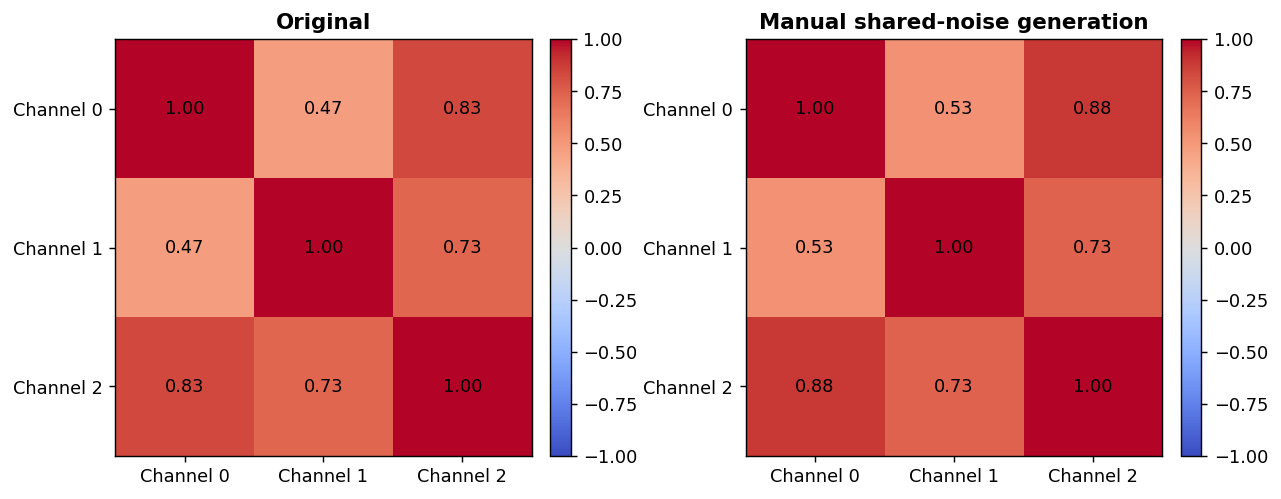

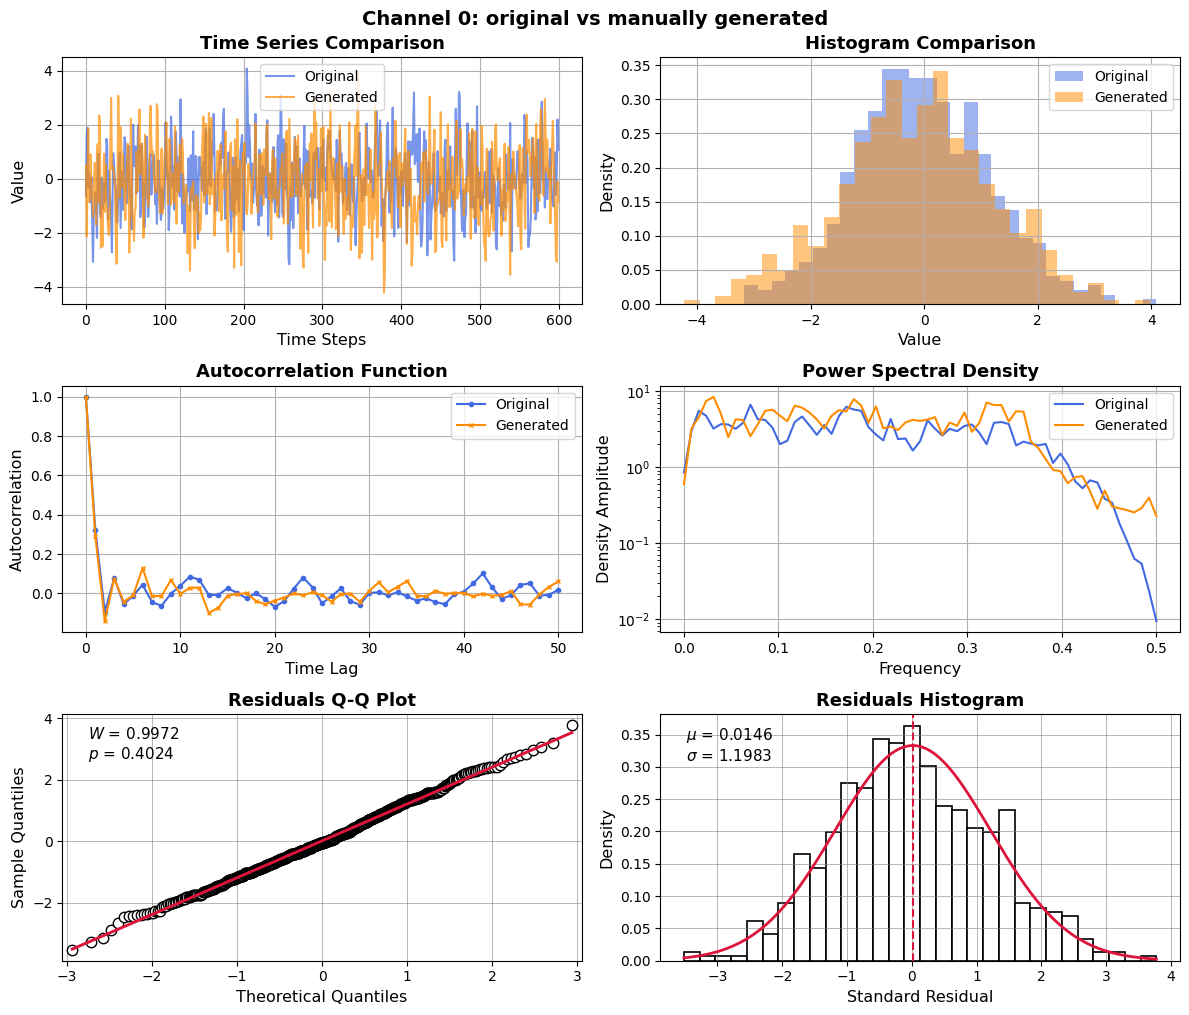

In [4]:
corr_original = np.corrcoef(time_series.T)
corr_generated = np.corrcoef(manual_generated.T)

fig, axes = plt.subplots(1, 2, figsize=(10, 4), dpi=128)
titles = ["Original", "Manual shared-noise generation"]

for ax, matrix, title in zip(axes, [corr_original, corr_generated], titles):
    im = ax.imshow(matrix, vmin=-1.0, vmax=1.0, cmap="coolwarm")
    ax.set_title(title, fontweight="bold")
    ax.set_xticks(range(n_channels))
    ax.set_yticks(range(n_channels))
    ax.set_xticklabels(channel_names)
    ax.set_yticklabels(channel_names)
    for i in range(n_channels):
        for j in range(n_channels):
            ax.text(
                j, i, f"{matrix[i, j]:.2f}", ha="center", va="center", color="black"
            )
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

plt.tight_layout()

fig = plot_simulator_statistics(
    original_series=time_series[:, 0],
    generated_series=manual_generated[:, 0],
    residuals=manual_simulators[0].residuals,
)
fig.suptitle(
    "Channel 0: original vs manually generated",
    fontsize=14,
    fontweight="bold",
    y=1.01,
)


The manual pipeline shows that a common white-noise excitation can reproduce correlated multivariate structure after per-channel fitting.

---

## Using `MultivariateSimulator` in S2Generator

The same workflow is encapsulated in `MultivariateSimulator`. We pass a single `WienerFilterSimulator` template, fit all channels in parallel, and generate new multivariate samples with one call to `transform`.


In [5]:
simulator = MultivariateSimulator(
    WienerFilterSimulator(filter_order=6, revin=True, random_state=42),
    n_jobs=-1,
)

simulator.fit(time_series)

print("Fit summary")
print(f"  n_channels : {simulator.n_channels}")
print(f"  simulator types : {[type(s).__name__ for s in simulator.simulators]}")

Fit summary
  n_channels : 3
  simulator types : ['WienerFilterSimulator', 'WienerFilterSimulator', 'WienerFilterSimulator']


Generated batch shape: (5, 600, 3)


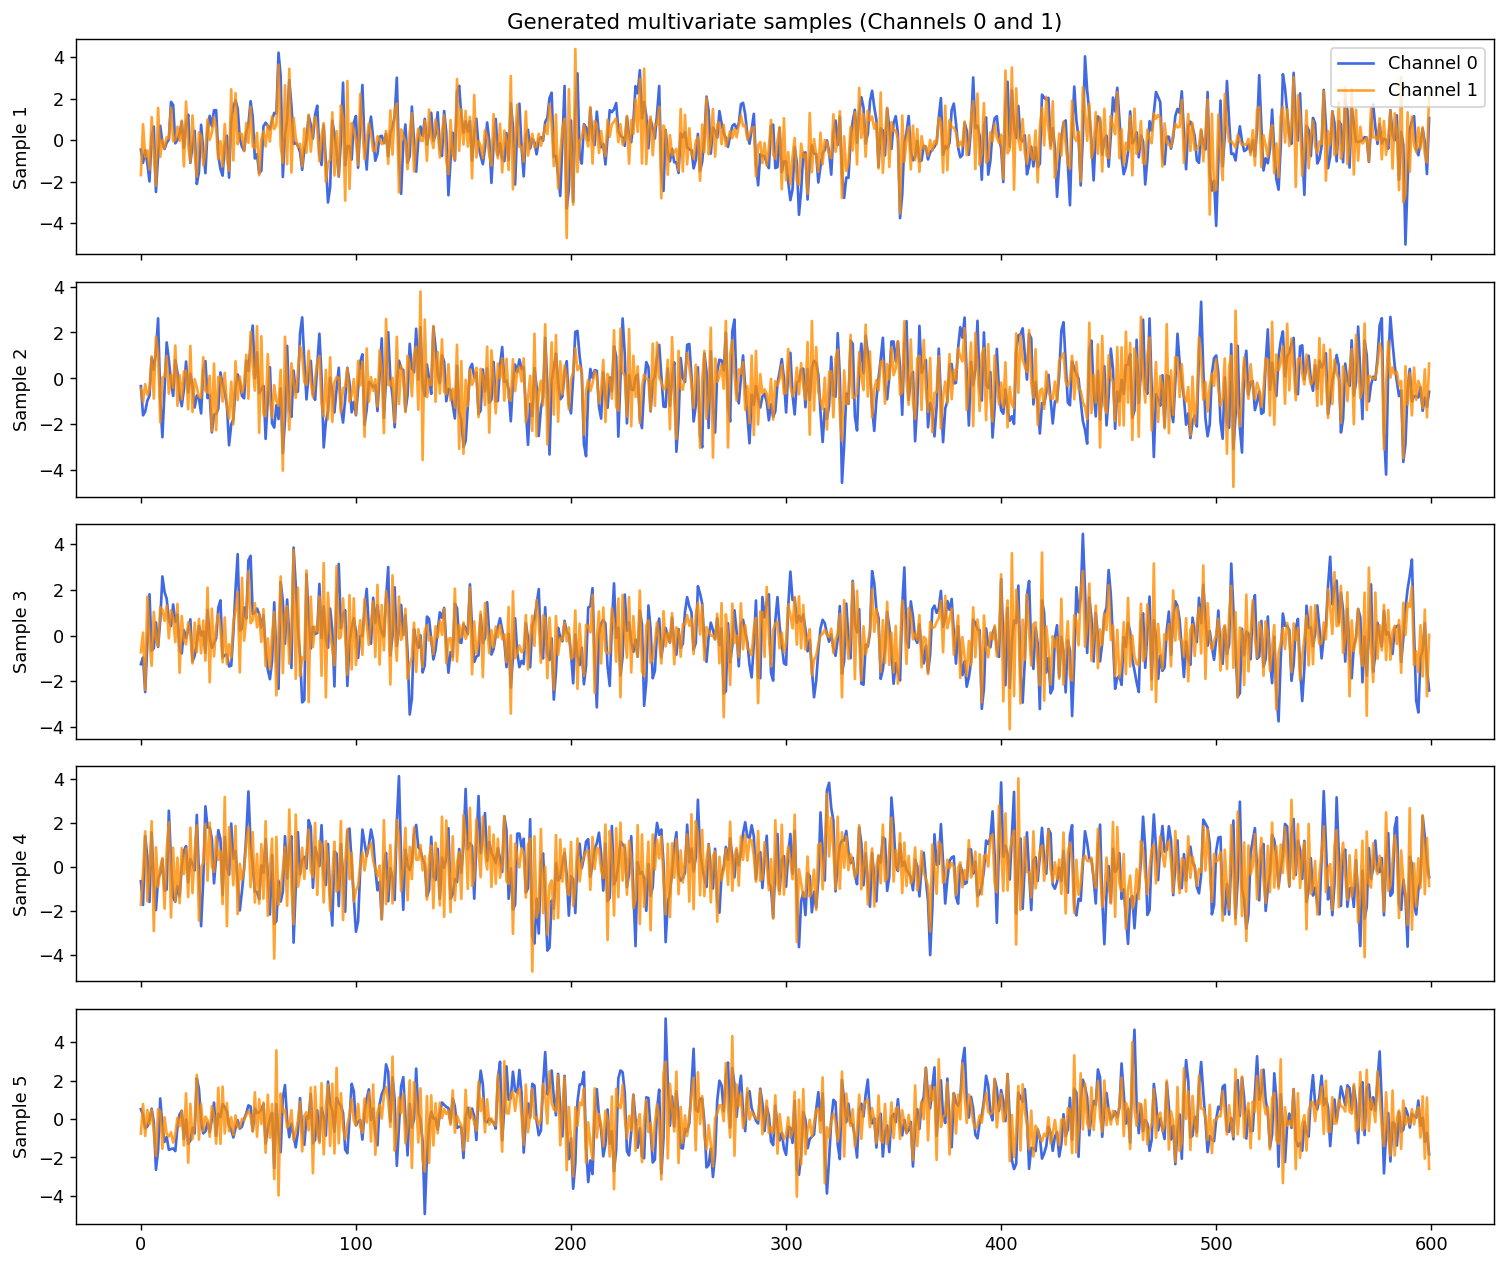

In [6]:
generated_batch = simulator.transform(
    num_samples=5,
    seq_length=seq_length,
    random_state=128,
)
print("Generated batch shape:", generated_batch.shape)

fig, axes = plt.subplots(5, 1, figsize=(12, 10), sharex=True, dpi=128)
for sample_index in range(generated_batch.shape[0]):
    axes[sample_index].plot(
        generated_batch[sample_index, :, 0],
        color="royalblue",
        label="Channel 0",
    )
    axes[sample_index].plot(
        generated_batch[sample_index, :, 1],
        color="darkorange",
        alpha=0.8,
        label="Channel 1",
    )
    axes[sample_index].set_ylabel(f"Sample {sample_index + 1}")
    if sample_index == 0:
        axes[sample_index].legend(loc="upper right")
axes[0].set_title("Generated multivariate samples (Channels 0 and 1)")
plt.tight_layout()

Text(0.5, 1.01, 'MultivariateSimulator: channel 0 vs original')

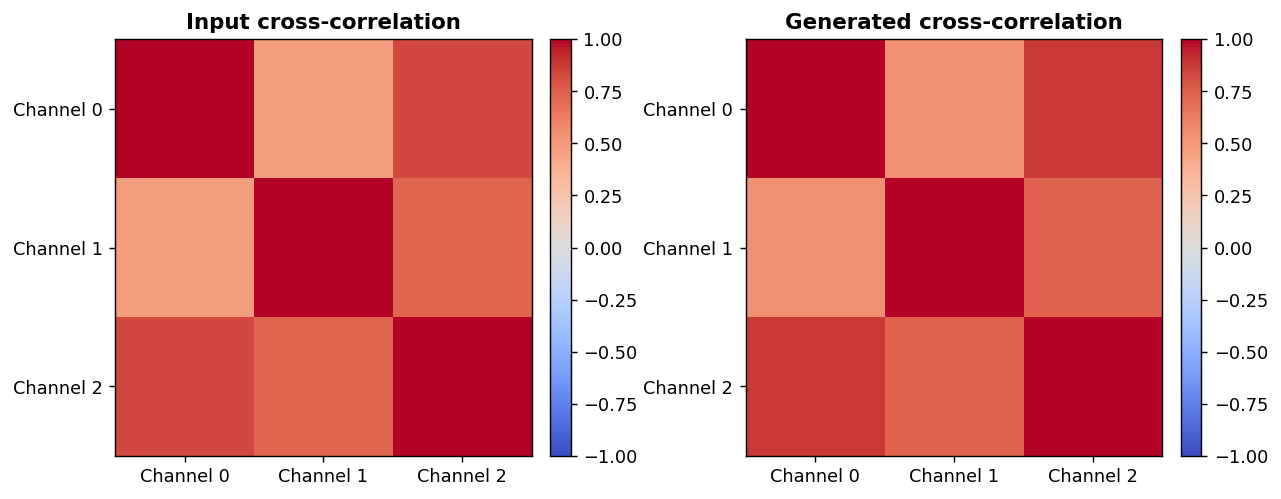

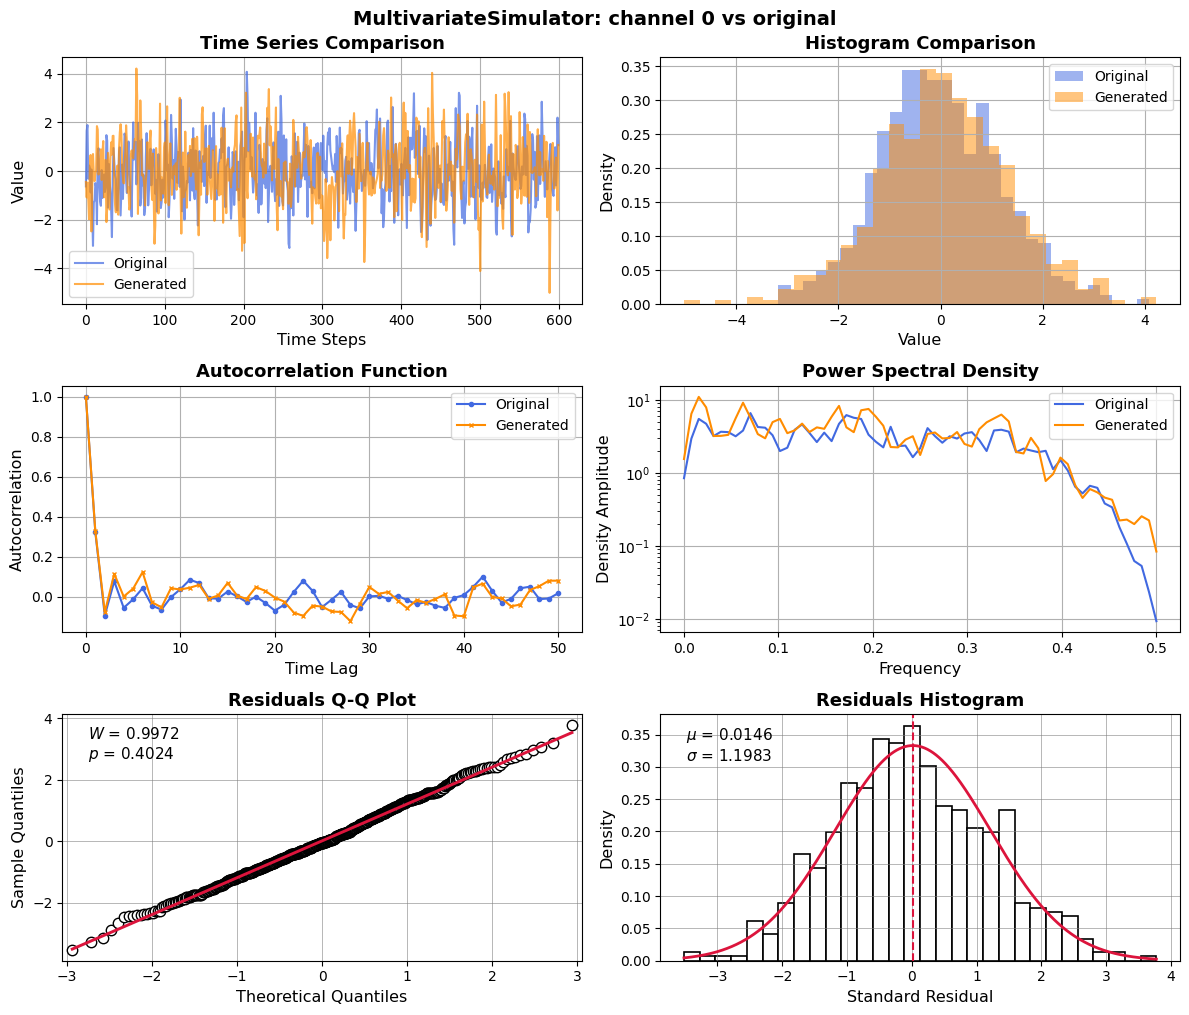

In [7]:
corr_input = np.corrcoef(time_series.T)
corr_output = np.corrcoef(generated_batch[0].T)

fig, axes = plt.subplots(1, 2, figsize=(10, 4), dpi=128)
for ax, matrix, title in zip(
    axes,
    [corr_input, corr_output],
    ["Input cross-correlation", "Generated cross-correlation"],
):
    im = ax.imshow(matrix, vmin=-1.0, vmax=1.0, cmap="coolwarm")
    ax.set_title(title, fontweight="bold")
    ax.set_xticks(range(n_channels))
    ax.set_yticks(range(n_channels))
    ax.set_xticklabels(channel_names)
    ax.set_yticklabels(channel_names)
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
plt.tight_layout()

fig = plot_simulator_statistics(
    original_series=time_series[:, 0],
    generated_series=generated_batch[0, :, 0],
    residuals=simulator.simulators[0].residuals,
)
fig.suptitle(
    "MultivariateSimulator: channel 0 vs original",
    fontsize=14,
    fontweight="bold",
    y=1.01,
)


### Supplementary demo: channel-specific simulator list

The following cell shows how to assign different simulator types to different channels. Any extra channel beyond the list length defaults to `WienerFilterSimulator`.


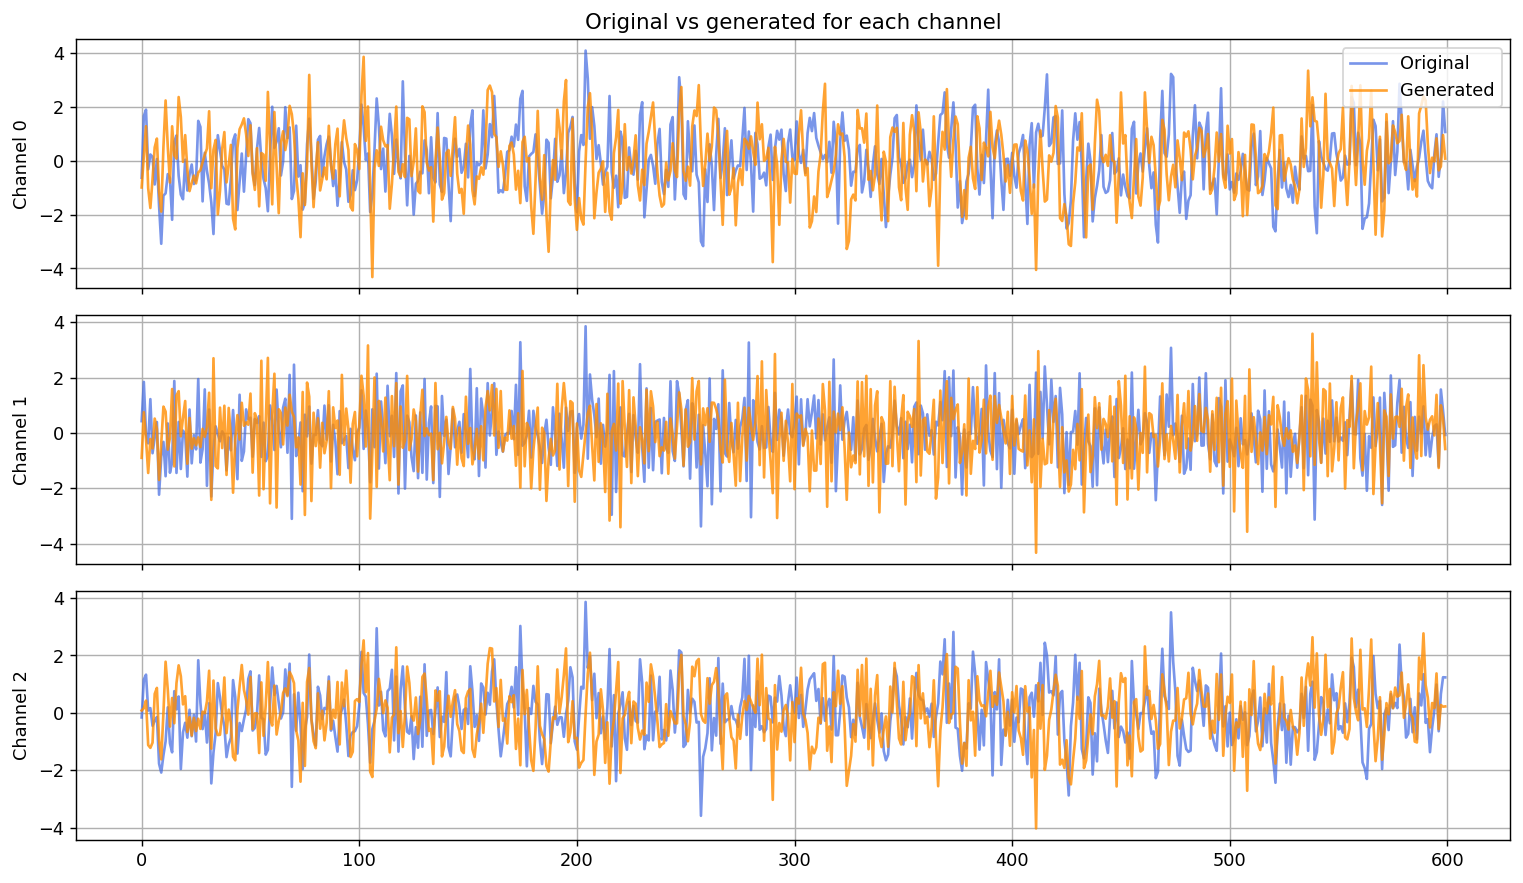

In [8]:
list_simulator = MultivariateSimulator(
    [
        WienerFilterSimulator(filter_order=5, random_state=0),
        KalmanFilterSimulator(state_order=5, random_state=1),
    ],
    n_jobs=1,
)
list_simulator.fit(time_series)

list_generated = list_simulator.transform(
    num_samples=1,
    seq_length=seq_length,
    random_state=11,
)[0]

fig, axes = plt.subplots(n_channels, 1, figsize=(12, 7), sharex=True, dpi=128)
for channel_index in range(n_channels):
    axes[channel_index].plot(
        time_series[:, channel_index],
        color="royalblue",
        alpha=0.7,
        label="Original",
    )
    axes[channel_index].plot(
        list_generated[:, channel_index],
        color="darkorange",
        alpha=0.8,
        label="Generated",
    )
    axes[channel_index].set_ylabel(channel_names[channel_index])
    axes[channel_index].grid(True)
    if channel_index == 0:
        axes[channel_index].legend(loc="upper right")
axes[0].set_title("Original vs generated for each channel")
plt.tight_layout()